# Lite Framework RAG Example

In [1]:
from IPython.display import display, HTML, Markdown
from rags import RAG
import re
from pydantic import BaseModel, Field
from ollama_tools import structured_output
from typing import List, Literal

DOCS_DIR = 'docs'
INDEX_DIR = 'rag_index'


def extract_html_part(text: str) -> str:
    """
    Extracts the HTML part from a string, detecting by either <!DOCTYPE html> or <html> tags.
    Discards any other tags like <think></think>.
    Returns the HTML string, or an empty string if not found.
    """
    # Try to match from <!DOCTYPE html ... </html>
    match = re.search(r'<!DOCTYPE html.*?</html>', text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(0)
    # If not found, try to match from <html ... </html>
    match = re.search(r'<html.*?</html>', text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(0)
    return ""

In [17]:
system_instr = """You are an expet at expanding the scope of financial questions to include more details to prepare it for earnings research from Bank earnings documents. 
You will be give a question containing Company Names, year_quarter (in the format YYYY_qn), and a list of metrics. Return the modified question containing more year quarters, more metrics and more companies.
Instructions:
1. If the user does not mention any companies, assume wells fargo. If the user mentions a company, only use that company
2. If the user does not mention any year quarters, assume 2025_q1, 2024_q4. Dont go to any month beyond 2025_q1. 
2.4 If the user says recently or this year, assume 2025_q1, 2024_q4
3. If the user does not mention any metrics, assume net interest income, net interest margin, and non-interest income (add more metrics if you can think of them)
4. Create the expanded question which contains the above details

Here are the company codes: 
1. Bank of America: boa
2. Citigroup: citi
3. JPMorgan Chase: jpmc
4. Wells Fargo: wfc
5. Goldman Sachs: gs
6. Morgan Stanley: ms


The output should be a JSON object with the following schema:
{
    "question": "string",
    "year_quarters": ["YYYY_qn", ...],
    "metrics": ["metric1", "metric2", ...],
    "companies": ["company1", "company2", ...]
}


"""
class SchemaModel(BaseModel):
    expanded_question: str = Field(..., description="The expanded question for earnings research.")
    year_quarters: list[str] = Field(..., description="List of year quarters in the format YYYY_qn.")
    metrics: list[str] = Field(..., description="List of financial metrics to be included in the research.")
    companies: list[Literal["boa", "jpmc", "citi"]] = Field(..., description="List of company codes to be included in the research.")
prompt = "comment on the net earnings of citi this year"

strop = structured_output(model = "qwen3:4b", schema_model = SchemaModel, prompt = prompt, system_instructions= system_instr, history = "")
strop

{'expanded_question': 'Comment on the net earnings of Citigroup (citi) for the year 2025_q1 and 2024_q4, including metrics such as net interest income, net interest margin, non-interest income, net income, and return on equity (ROE).',
 'year_quarters': ['2025_q1', '2024_q4'],
 'metrics': ['net interest income',
  'net interest margin',
  'non-interest income',
  'net income',
  'return on equity (ROE)'],
 'companies': ['citi']}

In [18]:
def create_filenames_for_filter(str_op):
    """
    Create filenames for the filter based on the structured output.
    """
    question = str_op['expanded_question']
    year_quarters = str_op['year_quarters']
    metrics = str_op['metrics']
    companies = str_op['companies']

    filenames = [comp + "_result_" + year_quarter + ".pdf" for comp in companies for year_quarter in year_quarters]

    return filenames

create_filenames_for_filter(strop)

['citi_result_2025_q1.pdf', 'citi_result_2024_q4.pdf']

In [2]:

rag = RAG(llm_model = "qwen3:8b", chunk_size = 5000, chunk_overlap=1000, 
          n_results=10, chunker = 'semantic')
rag.build_vector_store(DOCS_DIR)
rag.save_vector_store(INDEX_DIR)

/home/nitish/Documents/github/PublicReportResearch/rags.py:54: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaEmbeddings``.
  self.embeddings = OllamaEmbeddings(model=embedding_model)
/home/nitish/Documents/github/PublicReportResearch/rags.py:55: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import ChatOllama``.
  self.llm = ChatOllama(model=llm_model)
Cannot set gray non-stroke color because /'P40' is an invalid flo

In [20]:
question = "Compare JPMC and CITI for Q2 2024 earnings"
strop = structured_output(model = "qwen3:4b", schema_model = SchemaModel, prompt = question, system_instructions= system_instr, history = "")
filters = create_filenames_for_filter(strop)
print("filters", filters)

viz_queries = rag.evaluate_queries(queries=["Compare JPMC and CITI for Q2 2024 earnings"], filters = [filters], top_n=15)



filters ['jpmc_result_2024_q2.pdf', 'citi_result_2024_q2.pdf']


query,rank,file,page,snippet
Compare JPMC and CITI for Q2 2024 earnings,1,jpmc_result_2024_q2.pdf,2,"C o m p a r i s o n s n o t e d i n t h e s e c t i o n s b e l o w a r e f o r t h e s e c o n d q u a r t e r o f 2 0 2 4 v e r s u s t h e p r i o r - y e a r s e c o n d q u a r t e r , u n l e s s o t h e r w i s e s p e c i f i e d . J P M O R G A N"
Compare JPMC and CITI for Q2 2024 earnings,2,jpmc_result_2024_q2.pdf,1,1 5 . 5 % C a s h a n d m a r k e t a b l e s e c u r i t i e s 4 $ 1 . 5 T R O T C E e x . s i g n i f i c a n t i t e m s 2 2 0 % T o t a l L o s s - A b s o r b i n g C a p a c i t y 3 $ 5 3 4 B A v e r a g e l o a n s $ 1 . 3 T n R e p o r t e d r e v e n
Compare JPMC and CITI for Q2 2024 earnings,3,citi_result_2024_q2.pdf,2,"S e c o n d Q u a r t e r F i n a n c i a l R e s u l t s C i t i g r o u p C i t i g r o u p r e v e n u e s o f $ 2 0 . 1 b i l l i o n i n t h e s e c o n d q u a r t e r 2 0 2 4 i n c r e a s e d 4 % , o n a r e p o r t e d b a s i s . E x c l u d i n g"


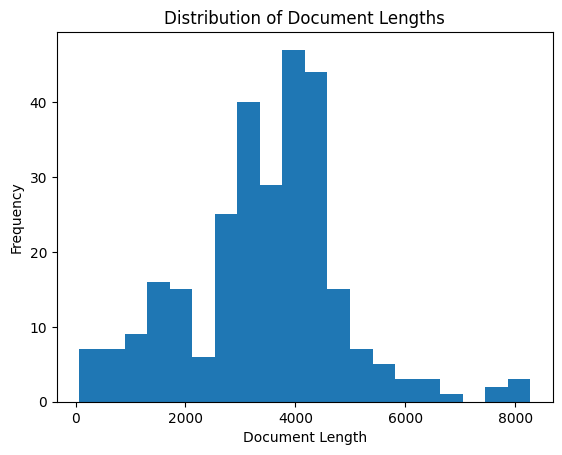

In [8]:
# Visualize the distribution of document lengths
import matplotlib.pyplot as plt

doc_lengths = [len(doc.page_content) for doc in rag.documents_store]
plt.hist(doc_lengths, bins=20)
plt.xlabel("Document Length")
plt.ylabel("Frequency")
plt.title("Distribution of Document Lengths")
plt.show()


In [4]:
#Markdown(rag.documents_store[40].metadata['tables_md'][0])
HTML(rag.documents_store[40].metadata['tables_html'][0])



"Provision for credit losses $1,319 $1,104 $931",
"Net charge-offs 1,498 1,192 807",
Net charge-off ratio2 0.58 % 0.45 % 0.32 %,
"At period-end Nonperforming loans and $5,883 $5,485 $3,918 leases",
,"$5,883 $5,485 $3,918"
Nonperforming loans and leases ratio,0.56 % 0.52 % 0.38 %
Allowance for credit losses,"$14,371 $14,551 $13,951"
Allowance for loan and lease losses,"13,213 13,342 12,514"
Allowance for loan and lease losses ratio3,1.26 % 1.27 % 1.20 %


In [14]:
Markdown(rag.documents_store[40].page_content)

Credit Quality1
Charge-offs Highlights
• Total net charge-offs of $1.5 billion increased Three months ended
$306 million from Q4-23
($ in millions) 3/31/2024 12/31/2023 3/31/2023
– Consumer net charge-offs of $1.0 billion increased
$115 million from Q4-23, driven primarily by Provision for credit losses $1,319 $1,104 $931
higher credit card losses
Net charge-offs 1,498 1,192 807
– Credit card loss rate of 3.62% in Q1-24 vs. 3.07%
in Q4-23 Net charge-off ratio2 0.58 % 0.45 % 0.32 %
– Commercial net charge-offs of $470 million At period-end
increased $191 million from Q4-23, driven by
Nonperforming loans and $5,883 $5,485 $3,918
commercial real estate office
leases
• Net charge-off ratio2 of 0.58% increased 13 bps
Nonperforming loans and 0.56 % 0.52 % 0.38 %
from Q4-23
leases ratio
Allowance for credit losses $14,371 $14,551 $13,951
Provision for credit losses
Allowance for loan and lease 13,213 13,342 12,514
• Provision for credit losses of $1.3 billion
losses
– Net reserve release of $179 million in Q1-24,(D)
Allowance for loan and lease 1.26 % 1.27 % 1.20 %
driven primarily by commercial
losses ratio3
1 Comparisons are to the year-ago quarter unless noted.
Allowance for credit losses 2 Net charge-off ratio is calculated as annualized net charge-offs divided by average
outstanding loans and leases during the period.
• Allowance for loan and lease losses of $13.2 billion 3 Allowance for loan and lease losses ratio is calculated as allowance for loan and lease losses
represented 1.26% of total loans and leases3 divided by loans and leases outstanding at the end of the period.
– Total allowance for credit losses of $14.4 billion Note: Ratios do not include loans accounted for under the fair value option.
included $1.2 billion for unfunded commitments
• Nonperforming loans (NPLs) of $5.9 billion increased
$398 million from Q4-23, driven primarily by
commercial real estate office
– 61% of Consumer NPLs are contractually current
• Commercial reservable criticized utilized exposure of
$24.5 billion increased $1.2 billion from Q4-23
8

In [5]:
rag2 = RAG(llm_model = "qwen2.5:7b")
rag2.load_vector_store(INDEX_DIR)
#result = rag2.invoke('Provide a long description of the earnings of citi bank in Q4 2024 and format it as a table. After the table, provide a short description of your findings')
result = rag2.invoke('compare citi and jpmc earnings in q1 2024 in html format')

print(result)

ValueError: The de-serialization relies loading a pickle file. Pickle files can be modified to deliver a malicious payload that results in execution of arbitrary code on your machine.You will need to set `allow_dangerous_deserialization` to `True` to enable deserialization. If you do this, make sure that you trust the source of the data. For example, if you are loading a file that you created, and know that no one else has modified the file, then this is safe to do. Do not set this to `True` if you are loading a file from an untrusted source (e.g., some random site on the internet.).

In [10]:
print(result[0]['context'][0])

page_content='Comparisons noted in the sections below are for the second quarter of 2024 versus the prior-year second quarter, unless
otherwise specified. JPMORGAN CHASE (JPM)
Results for JPM 1Q24 2Q23
($ millions, except per share data) 2Q24 1Q24 2Q23 $ O/(U) O/(U) % $ O/(U) O/(U) %
Net revenue - reported $ 50,200 $ 41,934 $ 41,307 $ 8,266 20 % $ 8,893 22 %
Net revenue - managed 50,992 42,548 42,401 8,444 20 8,591 20
Noninterest expense 23,713 22,757 20,822 956 4 2,891 14
Provision for credit losses 3,052 1,884 2,899 1,168 62 153 5
Net income $ 18,149 $ 13,419 $ 14,472 $ 4,730 35 % $ 3,677 25 %
Earnings per share - diluted $ 6.12 $ 4.44 $ 4.75 $ 1.68 38 % $ 1.37 29 %
Return on common equity 23 % 17 % 20 %
Return on tangible common equity 28 21 25
Discussion of Results:
Net income was $18.1 billion, up 25%, including a $7.9 billion net gain related to Visa shares and a $1.0 billion donation of
Visa shares to pre-fund contributions to the Firm’s Foundation. Net revenue was $51.0 billion

In [6]:
with open('result.html', 'w') as f:
    f.write(result[result.find("<!DOCTYPE html>")+0:])

In [9]:
with open('result.html', 'w') as f:
    f.write(extract_html_part(result))



In [10]:
extract_html_part(result)


'<!DOCTYPE html>\n<html lang="en">\n<head>\n    <meta charset="UTF-8">\n    <meta name="viewport" content="width=device-width, initial-scale=1">\n    <title>Citi vs JPMorgan Chase Q4 2024 Earnings Comparison</title>\n    <style>\n        body {\n            font-family: Arial, sans-serif;\n            margin: 40px;\n            background-color: #f9f9f9;\n        }\n        h1 {\n            color: #333;\n        }\n        table {\n            width: 100%;\n            border-collapse: collapse;\n            margin-top: 20px;\n        }\n        th, td {\n            padding: 12px 15px;\n            border: 1px solid #ccc;\n            text-align: center;\n        }\n        th {\n            background-color: #007BFF;\n            color: white;\n        }\n        tr:nth-child(even) {\n            background-color: #f2f2f2;\n        }\n        .disclaimer {\n            margin-top: 30px;\n            font-style: italic;\n            color: #555;\n        }\n    </style>\n</head>\n<bo

In [11]:
enumerate?

Init signature: enumerate(iterable, start=0)
Docstring:     
Return an enumerate object.

  iterable
    an object supporting iteration

The enumerate object yields pairs containing a count (from start, which
defaults to zero) and a value yielded by the iterable argument.

enumerate is useful for obtaining an indexed list:
    (0, seq[0]), (1, seq[1]), (2, seq[2]), ...
Type:           type
Subclasses:     